<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# LDA PERFORMANCE ASSESSMENT - TITANIC DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/train_and_test2.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1309, 28)
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1        0        0       2.0   
4       0  ...        0        0        0       3        0        0       2.0   

   zero.17  zero.18  2urvived  
0   

In [ ]:

# ------------------------------------------------------------
# 2. Separate Features and Target
# ------------------------------------------------------------

X = df.drop("2urvived", axis=1)
y = df["2urvived"]

In [ ]:


# ------------------------------------------------------------
# 3. Remove unnecessary / constant columns
# ------------------------------------------------------------

# Remove Passenger ID
X = X.drop("Passengerid", axis=1)

# Remove columns having only one unique value
constant_columns = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

X = X.drop(columns=constant_columns)

print("\nRemoved constant columns:", constant_columns)
print("Remaining features:", X.shape[1])



Removed constant columns: ['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18']
Remaining features: 7


In [ ]:


# ------------------------------------------------------------
# 4. Handle Missing Values
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(X)


In [ ]:


# ------------------------------------------------------------
# 5. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:

# ------------------------------------------------------------
# 6. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:


# ------------------------------------------------------------
# 7. Create LDA Model
# ------------------------------------------------------------

lda = LinearDiscriminantAnalysis()

# Train
lda.fit(X_train, y_train)


LinearDiscriminantAnalysis()

In [ ]:


# ------------------------------------------------------------
# 8. Predictions
# ------------------------------------------------------------

y_train_pred = lda.predict(X_train)
y_test_pred = lda.predict(X_test)

# Probability for ROC-AUC
y_test_prob = lda.predict_proba(X_test)[:, 1]

In [ ]:



# ------------------------------------------------------------
# 9. Performance Metrics
# ------------------------------------------------------------

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

roc_auc = roc_auc_score(y_test, y_test_prob)

print("\n================ LDA PERFORMANCE ================")

print("Training Accuracy :", round(train_accuracy, 4))
print("Testing Accuracy  :", round(test_accuracy, 4))
print("Precision         :", round(precision, 4))
print("Recall            :", round(recall, 4))
print("F1-Score          :", round(f1, 4))
print("ROC-AUC           :", round(roc_auc, 4))


================ LDA PERFORMANCE ================
Training Accuracy : 0.8032
Testing Accuracy  : 0.7481
Precision         : 0.52
Recall            : 0.3824
F1-Score          : 0.4407
ROC-AUC           : 0.7589


In [ ]:


# ------------------------------------------------------------
# 10. Classification Report
# ------------------------------------------------------------

print("\n================ CLASSIFICATION REPORT ================")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Did Not Survive", "Survived"]
    )
)


================ CLASSIFICATION REPORT ================
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.88      0.84       194
       Survived       0.52      0.38      0.44        68

       accuracy                           0.75       262
      macro avg       0.66      0.63      0.64       262
   weighted avg       0.73      0.75      0.73       262



In [ ]:


# ------------------------------------------------------------
# 11. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_test_pred)

print("\n================ CONFUSION MATRIX ================")
print(cm)


================ CONFUSION MATRIX ================
[[170  24]
 [ 42  26]]


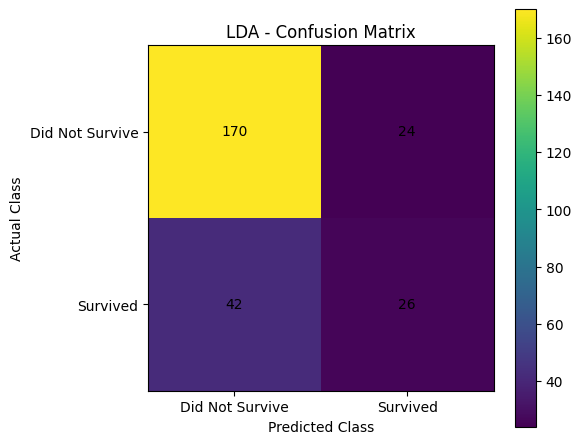

In [ ]:


# ------------------------------------------------------------
# 12. Plot Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("LDA - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

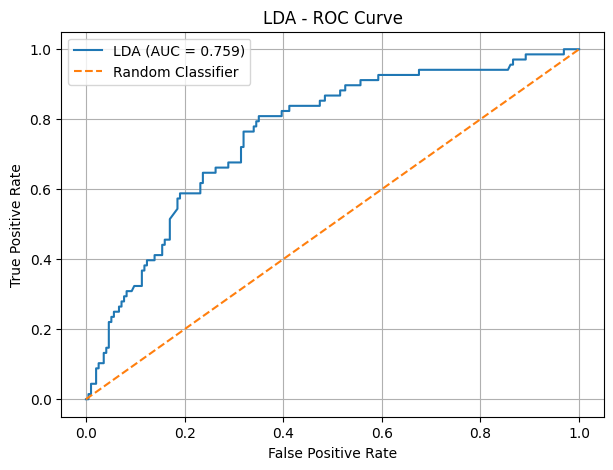

In [ ]:


# ------------------------------------------------------------
# 13. ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"LDA (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LDA - ROC Curve")
plt.legend()
plt.grid()
plt.show()

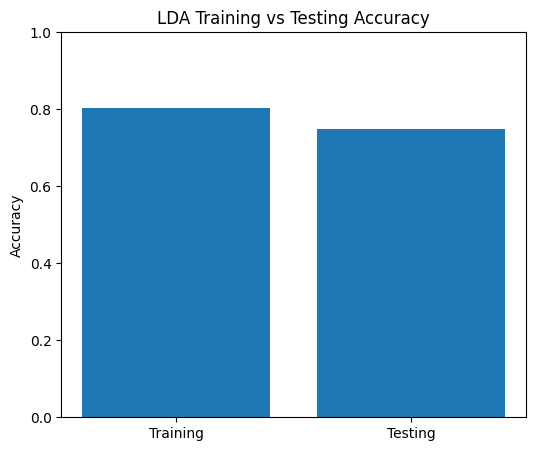

In [ ]:


# ------------------------------------------------------------
# 14. Training vs Testing Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.bar(
    ["Training", "Testing"],
    [train_accuracy, test_accuracy]
)

plt.ylabel("Accuracy")
plt.title("LDA Training vs Testing Accuracy")
plt.ylim(0, 1)

plt.show()